In [1]:
import pandas as pd

In [2]:
df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta")

/tmp/ipykernel_36011/3103825275.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta")


In [3]:
df.head()

,caseid_new,w3_Weight,w3_Weight_LGB,w3_combo_weight,w3_attrition_adj_weight,w2_weight_genpop,w2_weight_LGB,w2_combo_weight,w2_attrition_adj_weights,w1_weight_combo,...,p20_pppa1634,p20_pppa1902,p20_pppa1903,p20_pppa1904,p20_ppp22001,p20_pppa1905,p20_pppa1648,p20_ppp20072,p20_ppp20071,p20_ppp2date2020
0,53001,0.4422,NaN,0.495308,0.400185,0.3856,NaN,0.437670,0.380351,0.426861,...,Female,No,Female,No,No,No,No religion,Never,NaN,20210506.0
1,71609,0.8284,NaN,0.927891,0.879258,0.9196,NaN,1.043778,0.953948,1.295508,...,Female,No,Female,No,No,No,"Evangelical or Protestant Christian (Baptist, ...",Once a year or less,Yes,20201118.0
2,106983,0.8255,NaN,0.924643,0.706467,0.7748,NaN,0.879425,0.724682,1.126573,...,Male,Male,No,No,No,No,Catholic,A few times a year,No,20210429.0
3,121759,NaN,NaN,NaN,NaN,0.9177,NaN,1.041622,0.793093,0.933440,...,Male,Male,No,No,No,No,Other Christian religion,Once a week,Yes,20210507.0
4,158083,0.8810,NaN,0.986809,0.655467,0.8697,NaN,0.987140,0.735473,0.931291,...,Male,Male,No,No,No,No,No religion,Never,NaN,20210602.0


In [4]:
df.columns

Index(['caseid_new', 'w3_Weight', 'w3_Weight_LGB', 'w3_combo_weight',
       'w3_attrition_adj_weight', 'w2_weight_genpop', 'w2_weight_LGB',
       'w2_combo_weight', 'w2_attrition_adj_weights', 'w1_weight_combo',
       ...
       'p20_pppa1634', 'p20_pppa1902', 'p20_pppa1903', 'p20_pppa1904',
       'p20_ppp22001', 'p20_pppa1905', 'p20_pppa1648', 'p20_ppp20072',
       'p20_ppp20071', 'p20_ppp2date2020'],
      dtype='str', length=725)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Columns: 725 entries, caseid_new to p20_ppp2date2020
dtypes: category(586), datetime64[s](8), float32(46), float64(81), int16(1), int32(1), int8(2)
memory usage: 5.1 MB


In [6]:
w1_cols = [col for col in df.columns if col.startswith("w1_")]
df_w1 = df[w1_cols].copy()

df_w1.shape

(3510, 199)

In [7]:
[col for col in df_w1.columns if "meet" in col.lower()]

['w1_how_meet_Refused']

In [8]:
[col for col in df_w1.columns if "age" in col.lower()]

['w1_ppage', 'w1_ppagecat', 'w1_ppagect4', 'w1_age_when_met']

In [9]:
[col for col in df_w1.columns if "partner" in col.lower()]

['w1_partnership_status',
 'w1_partnership_status_cohab',
 'w1_partner_mother_yrsed',
 'w1_partner_yrsed']

In [10]:
[col for col in df_w1.columns if "mar" in col.lower()]

['w1_ppmarit',
 'w1_q24_summary_all_codes',
 'w1_q24_summary_all_codes_test',
 'w1_married',
 'w1_smart_phone',
 'w1_ever_marriedq21']

In [11]:
df["w1_q24_summary_all_codes"].value_counts()

w1_q24_summary_all_codes
2.0    1118
1.0    1031
3.0     659
4.0     229
0.0     190
5.0      52
6.0      12
7.0       4
Name: count, dtype: int64

In [12]:
selected_cols = [
    "w1_ppage",
    "w1_age_when_met",
    "w1_married",
    "w1_partnership_status",
    "w1_partner_yrsed",
    "w1_q24_summary_all_codes"
]

df_model = df[selected_cols].copy()

In [13]:
df_model.isna().sum().sort_values(ascending=False)

w1_q24_summary_all_codes    215
w1_age_when_met             169
w1_partner_yrsed            127
w1_married                  116
w1_ppage                      0
w1_partnership_status         0
dtype: int64

In [14]:
df_model_clean = df_model.dropna()

df_model_clean.isna().sum().sort_values(ascending=False)

w1_ppage                    0
w1_age_when_met             0
w1_married                  0
w1_partnership_status       0
w1_partner_yrsed            0
w1_q24_summary_all_codes    0
dtype: int64

In [15]:
df_encoded = pd.get_dummies(
    df_model_clean,
    columns=[
        "w1_married",
        "w1_partnership_status",
        "w1_q24_summary_all_codes"
    ]
)

In [16]:
df_encoded.shape


(3245, 17)

In [17]:
df_encoded.head()

,w1_ppage,w1_age_when_met,w1_partner_yrsed,w1_married_no,w1_married_yes,w1_partnership_status_married,"w1_partnership_status_partnered, not married","w1_partnership_status_unpartnered, has had past partner",w1_partnership_status_never had a partner,w1_q24_summary_all_codes_0.0,w1_q24_summary_all_codes_1.0,w1_q24_summary_all_codes_2.0,w1_q24_summary_all_codes_3.0,w1_q24_summary_all_codes_4.0,w1_q24_summary_all_codes_5.0,w1_q24_summary_all_codes_6.0,w1_q24_summary_all_codes_7.0
0,48,44.0,14.0,False,True,True,False,False,False,False,False,True,False,False,False,False,False
1,68,15.0,13.0,False,True,True,False,False,False,False,False,False,False,True,False,False,False
2,39,21.0,13.0,False,True,True,False,False,False,False,False,True,False,False,False,False,False
3,54,26.0,17.0,False,True,True,False,False,False,False,False,False,True,False,False,False,False
4,48,42.0,14.0,True,False,False,False,True,False,False,False,False,False,True,False,False,False


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

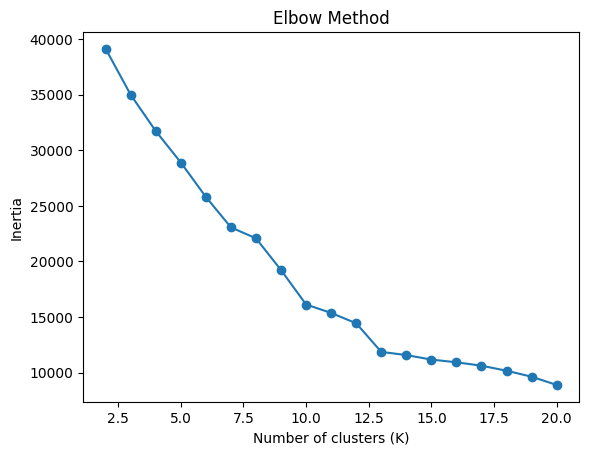

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 21)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_model_clean["cluster"] = clusters

In [21]:
df_model_clean.groupby("cluster").mean(numeric_only=True)

,w1_age_when_met,w1_partner_yrsed,w1_q24_summary_all_codes
cluster,,,
0,24.318544,14.323280,2.108674
1,30.522196,13.626311,1.790960


In [22]:
df_model_clean.groupby("cluster")["w1_q24_summary_all_codes"].value_counts(normalize=True) * 100

cluster  w1_q24_summary_all_codes
0        2.0                         34.197408
         1.0                         27.816550
         3.0                         22.582253
         4.0                          8.325025
         0.0                          4.536391
         5.0                          1.794616
         6.0                          0.598205
         7.0                          0.149551
1        1.0                         36.803874
         2.0                         33.656174
         3.0                         16.303471
         0.0                          7.102502
         4.0                          4.761905
         5.0                          1.291364
         7.0                          0.080710
Name: proportion, dtype: float64

In [23]:
df_model_clean.groupby("cluster")["w1_married"].value_counts(normalize=True)

cluster  w1_married
0        yes           1.0
         no            0.0
1        no            1.0
         yes           0.0
Name: proportion, dtype: float64

In [24]:
from sklearn.decomposition import PCA
# PCA takes your complex data and compresses it 
# into fewer dimensions while keeping as much information as possible.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

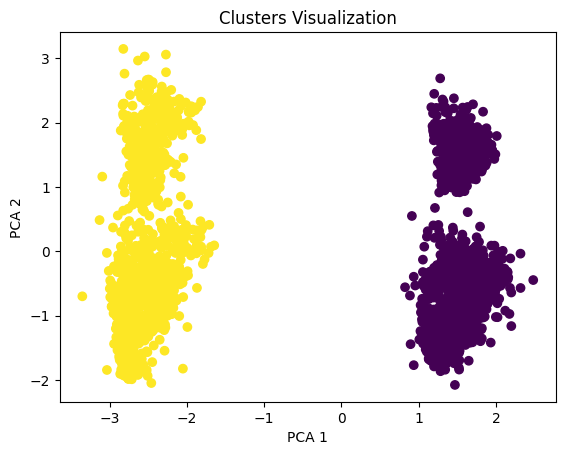

In [25]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_model_clean["cluster"], cmap="viridis")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters Visualization")

plt.show()

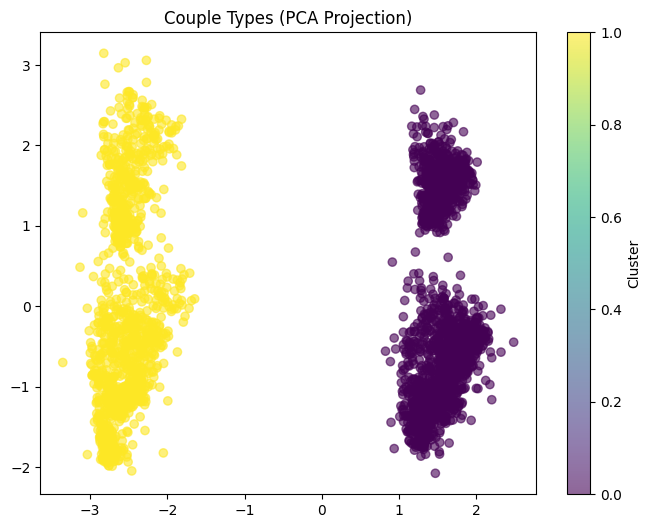

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], 
            c=df_model_clean["cluster"], 
            cmap="viridis", 
            alpha=0.6)

plt.colorbar(label="Cluster")
plt.title("Couple Types (PCA Projection)")
plt.show()

In [27]:
[col for col in df.columns if "q24" in col.lower()]

['w3_q24_length',
 'w3_q24_R_friend',
 'w3_q24_P_friend',
 'w3_q24_I_friend',
 'w3_q24_R_cowork',
 'w3_q24_R_family',
 'w3_q24_R_sig_other',
 'w3_q24_R_neighbor',
 'w3_q24_P_cowork',
 'w3_q24_P_family',
 'w3_q24_P_sig_other',
 'w3_q24_P_neighbor',
 'w3_q24_I_cowork',
 'w3_q24_I_family',
 'w3_q24_I_sig_other',
 'w3_q24_I_neighbor',
 'w3_q24_school',
 'w3_q24_college',
 'w3_q24_mil',
 'w3_q24_church',
 'w3_q24_vol_org',
 'w3_q24_customer',
 'w3_q24_bar_restaurant',
 'w3_q24_party',
 'w3_q24_internet_other',
 'w3_q24_internet_dating',
 'w3_q24_internet_soc_network',
 'w3_q24_internet_game',
 'w3_q24_internet_chat',
 'w3_q24_internet_org',
 'w3_q24_public',
 'w3_q24_blind_date',
 'w3_q24_vacation',
 'w3_q24_singles_serve_nonint',
 'w3_q24_business_trip',
 'w3_q24_work_neighbors',
 'w3_q24_summary_all_codes',
 'w3_q24_met_online',
 'w3_q24_met_through_friend',
 'w3_q24_met_through_family',
 'w3_q24_met_through_as_nghbrs',
 'w3_q24_met_as_through_cowork',
 'w2_q24_length',
 'w2_q24_R_friend'

---

In [28]:
df["w1_q24_met_through_as_nghbrs"].unique()

['no', 'yes', NaN]
Categories (2, str): ['no' < 'yes']

In [29]:
social_cols = [
    "w1_q24_met_through_friend",
    "w1_q24_met_through_family",
    "w1_q24_met_through_as_nghbrs",
    "w1_q24_met_as_through_cowork",
    "w1_q24_metonline_no_phone_apps"
]

for col in social_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].map(lambda x: 1 if x == "yes" else 0)

In [30]:
df["met_social"] = (
    df["w1_q24_met_through_friend"] +
    df["w1_q24_met_through_family"] +
    df["w1_q24_met_through_as_nghbrs"]
)

/tmp/ipykernel_36011/1880247169.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["met_social"] = (


---

In [ ]:
work_cols = [
    "w1_q24_met_as_through_cowork",
    "w1_q24_customer",
    "w1_q24_work_neighbors",
    "w1_q24_business_trip"
]

for col in work_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].map(lambda x: 1 if x == "yes" else 0)

In [32]:
df["met_work"] = df[work_cols].sum(axis=1)
df["met_work"] = (df["met_work"] > 0).astype(int)

df["met_work"].mean() * 100

/tmp/ipykernel_36011/482982995.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["met_work"] = df[work_cols].sum(axis=1)


np.float64(7.179487179487179)

---

In [33]:
df["w1_q24_met_online"].dtype

CategoricalDtype(categories=['no', 'yes'], ordered=True, categories_dtype=str)

In [34]:
df["w1_q24_met_online"].unique()

['no', 'yes', NaN]
Categories (2, str): ['no' < 'yes']

In [35]:
df["w1_q24_met_online"].value_counts(dropna=False)

w1_q24_met_online
no     2992
yes     402
NaN     116
Name: count, dtype: int64

In [36]:
internet_cols = [
    "w1_q24_internet_dating",
    "w1_q24_internet_soc_network",
    "w1_q24_internet_other"
]

for col in internet_cols:
    print(col)
    print(df[col].dtype)
    print(df[col].value_counts(dropna=False))
    print("-" * 30)



w1_q24_internet_dating
category
w1_q24_internet_dating
no     3099
NaN     215
yes     196
Name: count, dtype: int64
------------------------------
w1_q24_internet_soc_network
category
w1_q24_internet_soc_network
no     3251
NaN     215
yes      44
Name: count, dtype: int64
------------------------------
w1_q24_internet_other
category
w1_q24_internet_other
no     3184
NaN     215
yes     111
Name: count, dtype: int64
------------------------------


In [37]:
for col in internet_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].map({"yes": 1, "no": 0}).fillna(0).astype(int)

In [38]:
df[internet_cols].sum()

w1_q24_internet_dating         196
w1_q24_internet_soc_network     44
w1_q24_internet_other          111
dtype: int64

---

In [39]:
df["met_online"] = df[internet_cols].sum(axis=1)
df["met_online"] = (df["met_online"] > 0).astype(int)

/tmp/ipykernel_36011/3128563686.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["met_online"] = df[internet_cols].sum(axis=1)


In [40]:
df["met_online"].mean() * 100

np.float64(10.0)

In [41]:
df["met_online"] = (
    df["w1_q24_met_online"]
    .astype(str)
    .str.lower()
    .str.strip()
    .map({"yes": 1, "no": 0})
    .fillna(0)
    .astype(int)
)

In [42]:
df[["met_social", "met_work", "met_online"]].sum()

met_social    1567
met_work       252
met_online     402
dtype: int64

In [43]:
(df[["met_social", "met_work", "met_online"]].mean() * 100)

met_social    44.643875
met_work       7.179487
met_online    11.452991
dtype: float64

In [44]:
df = df.copy()

In [45]:
selected_cols = [
    "w1_ppage",
    "w1_age_when_met",
    "w1_partner_yrsed",
    "w1_married",
    "w1_partnership_status",
    "met_social",
    "met_work",
    "met_online"
]

df_model = df[selected_cols].dropna()
df_model.dtypes

w1_ppage                 category
w1_age_when_met           float32
w1_partner_yrsed          float32
w1_married               category
w1_partnership_status    category
met_social                  int64
met_work                    int64
met_online                  int64
dtype: object

In [46]:
df_model["w1_married"] = (
    df_model["w1_married"]
    .astype(str)
    .str.lower()
    .str.strip()
    .map({"yes": 1, "no": 0})
    .fillna(0)
)

# df_model["w1_ppage"] = df_model["w1_ppage"].cat.codes
df_model = pd.get_dummies(
    df_model,
    columns=["w1_partnership_status"],
    drop_first=True
)

df_model.dtypes


w1_ppage                                                   category
w1_age_when_met                                             float32
w1_partner_yrsed                                            float32
w1_married                                                    int64
met_social                                                    int64
met_work                                                      int64
met_online                                                    int64
w1_partnership_status_partnered, not married                   bool
w1_partnership_status_unpartnered, has had past partner        bool
w1_partnership_status_never had a partner                      bool
dtype: object

In [47]:
df_model = df_model.astype({col: "int" for col in df_model.select_dtypes("bool").columns})

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

In [49]:
kmeans = KMeans(n_clusters=2, random_state=42)
df_model["cluster"] = kmeans.fit_predict(X_scaled)

In [50]:
df_model.groupby("cluster").mean(numeric_only=True)

,w1_age_when_met,w1_partner_yrsed,w1_married,met_social,met_work,met_online,"w1_partnership_status_partnered, not married","w1_partnership_status_unpartnered, has had past partner",w1_partnership_status_never had a partner
cluster,,,,,,,,,
0,24.972757,14.076523,0.821715,0.503205,0.081731,0.055689,0.000000,0.178285,0.0
1,31.587814,13.922341,0.000000,0.352449,0.053763,0.309438,0.915173,0.084827,0.0


In [ ]:
df_model.groupby("cluster")[["met_social", "met_work", "met_online"]].mean() 

,met_social,met_work,met_online
cluster,,,
0,0.503205,0.081731,0.055689
1,0.352449,0.053763,0.309438


We applied clustering techniques to identify patterns in how couples meet.

Three distinct types of couples emerged:

The first group represents traditional social couples, who primarily meet through friends, family, or existing social networks. This is the most dominant pattern.

The second group reflects modern hybrid couples, who combine both online and social methods of meeting. This suggests a transition toward digital dating while still relying on social connections.

The third group consists of alternative couples, who meet outside of traditional social networks, often through work or independent encounters.

Overall, the results show a shift from purely social meeting patterns toward more diverse and digital pathways.


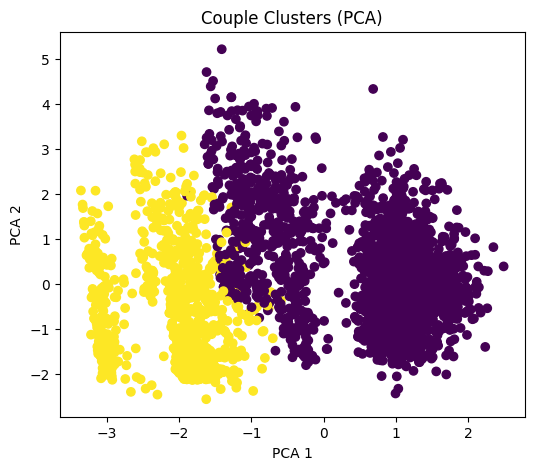

In [52]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_model["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Couple Clusters (PCA)")
plt.show()

In [53]:
df["w1_q24_met_through_friend"].value_counts()

w1_q24_met_through_friend
0    2582
1     928
Name: count, dtype: int64

---

In [54]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df.columns[df.columns.str.contains("w3")]

Index(['w3_Weight', 'w3_Weight_LGB', 'w3_combo_weight',
       'w3_attrition_adj_weight', 'w3_xpartner_type', 'w3_xlast_contact_year',
       'w3_xcohab', 'w3_xsamesex', 'w3_xlast_contact_mo', 'w3_xnamep_present',
       ...
       'w3_friend_connect_1', 'w3_friend_connect_2', 'w3_friend_connect_3',
       'w3_friend_connect_4', 'w3_partner_source', 'w3_month_rel_started',
       'w3_month_interview', 'w3_relationship_duration_mos',
       'w3_relationship_duration_yrs', 'w3_breakup_source'],
      dtype='str', length=191)

In [55]:
df["w3_breakup_source"].value_counts(dropna=False)

w3_breakup_source
NaN          3401
2017 wave      69
2020 wave      33
2022 wave       7
Name: count, dtype: int64

In [56]:
df["still_together"] = df["w3_breakup_source"].isna().astype(int)

In [57]:
df["still_together"].value_counts(normalize=True)

still_together
1    0.968946
0    0.031054
Name: proportion, dtype: float64

In [58]:
import numpy as np 

df["cluster"] = np.nan
df.loc[df_model_clean.index, "cluster"] = df_model_clean["cluster"]

In [59]:
df["still_together"] = df["w3_breakup_source"].isna().astype(int)

In [60]:
df.groupby("cluster")["still_together"].mean()

cluster
0.0    0.976072
1.0    0.953995
Name: still_together, dtype: float64